# LexAR - Fase 3: Clasificacion de pares candidatos

Clasifica los pares candidatos de `outputs/analysis_candidates.parquet` (salida de la Fase 2) en
`possible_conflict | possible_overlap | possible_modification | different_scope | neutral | needs_review`,
combinando reglas deterministas con un LLM en dos niveles (triage + verificacion) via Vertex AI.

La etiqueta es una **hipotesis priorizada para revision humana**, no una afirmacion juridica. Ver
`README.md` (plan de trabajo, seccion Fase 3) y `CLAUDE.md` para contexto completo del proyecto.

## 0. Dependencias

Mismo `requirements.txt` de la raiz del repo que las Fases 1-2 (ya incluye `google-genai` para Vertex AI).

In [1]:
# Ejecutar solo si faltan dependencias.
# %pip install -r ../requirements.txt

In [2]:
from __future__ import annotations

import gc
import json
import os
import re
import threading
import time
import unicodedata
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 220)

## 1. Configuracion

In [ ]:
ROOT = Path.cwd()
if not (ROOT / "outputs").exists() and (ROOT.parent / "outputs").exists():
    # Soporta lanzar Jupyter tanto desde la raiz del repo como desde notebooks/.
    ROOT = ROOT.parent

DATASET_DIR = ROOT / "data" / "lexar_datos_infoleg_saij"
RELATIONS_PATH = DATASET_DIR / "infoleg" / "procesado" / "relations.csv"
OUTPUT_DIR = ROOT / "outputs"
CANDIDATES_PATH = OUTPUT_DIR / "analysis_candidates.parquet"
FRAGMENTS_PATH = OUTPUT_DIR / "embedding_fragments.parquet"

CLASSIFICATION_DIR = OUTPUT_DIR / "classification"
CLASSIFICATION_DIR.mkdir(parents=True, exist_ok=True)
VERIFY_DIR = OUTPUT_DIR / "classification_verify"
VERIFY_DIR.mkdir(parents=True, exist_ok=True)

# Vertex AI: mismo proyecto y auth ADC configurados en la Fase 2 (ver CLAUDE.md).
GCP_PROJECT = os.environ.get("GOOGLE_CLOUD_PROJECT", "lexar-501717")
GCP_LOCATION = "us-central1"
TRIAGE_MODEL = "gemini-2.5-flash-lite"
VERIFY_MODEL = "gemini-2.5-flash"
PROMPT_VERSION = "v1"

# Umbral de similitud heredado de la Fase 2 (percentil 90 observado sobre 679.720 pares: ~0.957).
SIMILARITY_THRESHOLD = 0.957

# None = clasificar todos los pares sobre el umbral. Bajar para una corrida de prueba barata.
MAX_PAIRS_FOR_CLASSIFICATION = None

# Regla "near_identical": similitud minima para asumir solapamiento textual directo.
NEAR_IDENTICAL_THRESHOLD = 0.999

# Regla "boilerplate": grado minimo (cantidad de pares en los que aparece un fragmento) para
# sospechar de un fragmento de formula (clausulas de cierre, remisiones, etc.).
BOILERPLATE_MIN_DEGREE = 30

CLASSIFY_MAX_WORKERS = 5
CHECKPOINT_EVERY = 20

RANDOM_SEED = 42

CLASSIFICATION_LABELS = [
    "possible_conflict",
    "possible_overlap",
    "possible_modification",
    "different_scope",
    "neutral",
    "needs_review",
]

assert CANDIDATES_PATH.exists(), CANDIDATES_PATH
assert FRAGMENTS_PATH.exists(), FRAGMENTS_PATH
assert GCP_PROJECT != "TU-PROJECT-ID", "Completar GCP_PROJECT en la celda de configuracion."

CANDIDATES_PATH, FRAGMENTS_PATH, OUTPUT_DIR

## 2. Carga y preparacion de pares a clasificar

Se parte de `analysis_candidates.parquet` (679.720 pares, Fase 2), se recorta al umbral de similitud
y se le suma el texto y metadatos de ambos fragmentos.

In [4]:
candidates = pd.read_parquet(CANDIDATES_PATH)
print(f"Pares candidatos totales (Fase 2): {len(candidates):,}")

scoped = candidates[candidates["similarity_score"] >= SIMILARITY_THRESHOLD].copy()
print(f"Pares con similarity_score >= {SIMILARITY_THRESHOLD}: {len(scoped):,}")

if MAX_PAIRS_FOR_CLASSIFICATION is not None:
    # Muestra aleatoria (no el top por similitud): los pares con mayor similitud son casi todos
    # near-duplicados que la regla near_identical resuelve sin LLM, lo que dejaria un smoke test
    # sin pares para clasificar.
    scoped = scoped.sample(n=min(len(scoped), MAX_PAIRS_FOR_CLASSIFICATION), random_state=RANDOM_SEED).copy()
    print(f"Recortado a MAX_PAIRS_FOR_CLASSIFICATION={MAX_PAIRS_FOR_CLASSIFICATION}: {len(scoped):,}")

del candidates
gc.collect()

fragments = pd.read_parquet(
    FRAGMENTS_PATH,
    columns=["fragment_id", "text", "tipo_norma"],
).set_index("fragment_id")

scoped["text_a"] = scoped["fragment_a_id"].map(fragments["text"])
scoped["text_b"] = scoped["fragment_b_id"].map(fragments["text"])
scoped["tipo_norma_a"] = scoped["fragment_a_id"].map(fragments["tipo_norma"])
scoped["tipo_norma_b"] = scoped["fragment_b_id"].map(fragments["tipo_norma"])

missing_text = scoped["text_a"].isna() | scoped["text_b"].isna()
if missing_text.any():
    print(f"Advertencia: {missing_text.sum()} pares sin texto (fragment_id no encontrado), se descartan.")
    scoped = scoped[~missing_text].copy()

del fragments
gc.collect()

scoped[["pair_key", "similarity_score", "tipo_norma_a", "tipo_norma_b"]].head()

Pares candidatos totales (Fase 2): 679,720
Pares con similarity_score >= 0.957: 68,050
Recortado a MAX_PAIRS_FOR_CLASSIFICATION=100: 100


,pair_key,similarity_score,tipo_norma_a,tipo_norma_b
65631,frag:00075203|frag:00075528,0.958118,Ley,Ley
35567,frag:00015182|frag:00029244,0.973161,Ley,Ley
14112,frag:00106829|frag:00106944,0.984982,Ley,Ley
2008,frag:00092516|frag:00098391,0.997922,Ley,Ley
18035,frag:00089751|frag:00089909,0.982559,Ley,Ley


### 2.1 Contexto del grafo de modificaciones (Infoleg)

`relations.csv` vincula normas que se modifican entre si a nivel documento (no de articulo puntual). Se usa como pista en el prompt, no como etiqueta automatica.

In [5]:
relations = pd.read_csv(RELATIONS_PATH, usecols=["source_document_id", "target_document_id", "relation_type"])
relation_pairs = set(
    frozenset(pair) for pair in zip(relations["source_document_id"], relations["target_document_id"])
)

scoped["has_infoleg_relation"] = [
    frozenset((a, b)) in relation_pairs
    for a, b in zip(scoped["document_a_id"], scoped["document_b_id"])
]
print(
    f"Pares cuyos documentos ya estan vinculados en relations.csv: "
    f"{scoped['has_infoleg_relation'].sum():,} ({scoped['has_infoleg_relation'].mean():.1%})"
)

del relations, relation_pairs
gc.collect()

Pares cuyos documentos ya estan vinculados en relations.csv: 14 (14.0%)


0

## 3. Reglas deterministas (antes del LLM)

El README pide clasificar con "reglas + LLM". Dos reglas conservadoras resuelven una porcion de los
pares sin gastar llamadas al modelo, y quedan registradas con `rule_applied` para trazabilidad:

- **`rule:near_identical`**: similitud >= 0.999 o texto normalizado identico -> `possible_overlap`.
  Texto practicamente igual entre documentos distintos es redundancia por definicion.
- **`rule:boilerplate`**: dos señales independientes, cada una suficiente por si sola -> `neutral`.
  (a) formula de cierre tipo "comuniquese al Poder Ejecutivo" presente en AMBOS fragmentos (la fecha
  y los firmantes varian articulo a articulo, asi que exigir un umbral de grado aca descartaria
  la mayoria de estos casos reales); (b) ambos fragmentos son nodos de alto grado en el grafo de
  candidatos (aparecen en muchos pares), señal de clausula generica repetida aunque no matchee el
  patron de cierre — por ejemplo remisiones procedimentales estandar como el fragmento de
  jurisdiccion de tribunales federales visto en la Fase 2 (grado 117). Se exige la condicion en
  ambos lados del par (no solo uno) para ser conservadores.

In [6]:
def normalize_text(text: str) -> str:
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = re.sub(r"\s+", " ", text).strip().lower()
    return text


scoped["norm_text_a"] = scoped["text_a"].map(normalize_text)
scoped["norm_text_b"] = scoped["text_b"].map(normalize_text)

scoped["rule_applied"] = None
scoped["rule_label"] = None
scoped["rule_confidence"] = np.nan

is_near_identical = (
    (scoped["similarity_score"] >= NEAR_IDENTICAL_THRESHOLD)
    | (scoped["norm_text_a"] == scoped["norm_text_b"])
)
scoped.loc[is_near_identical, "rule_applied"] = "rule:near_identical"
scoped.loc[is_near_identical, "rule_label"] = "possible_overlap"
scoped.loc[is_near_identical, "rule_confidence"] = 0.95
print(f"rule:near_identical: {is_near_identical.sum():,} pares")

rule:near_identical: 2 pares


In [7]:
BOILERPLATE_PATTERNS = re.compile(
    r"comuniquese al poder ejecutivo"
    r"|dada en la sala de sesiones"
    r"|el poder ejecutivo nacional reglamentar"
    r"|la presente (ley|medida) (comenzara a regir|entrara en vigencia)"
    r"|de forma\.?\s*$"
    r"|regist(rese|rada)?,?\s*comuniquese"
    r"|publiquese,?\s*dese a la direccion nacional del registro oficial",
    re.IGNORECASE,
)

fragment_ids = pd.concat([scoped["fragment_a_id"], scoped["fragment_b_id"]])
fragment_degree = fragment_ids.value_counts()

is_boilerplate_text_a = scoped["norm_text_a"].str.contains(BOILERPLATE_PATTERNS, regex=True, na=False)
is_boilerplate_text_b = scoped["norm_text_b"].str.contains(BOILERPLATE_PATTERNS, regex=True, na=False)
is_high_degree_a = scoped["fragment_a_id"].map(fragment_degree).fillna(0) >= BOILERPLATE_MIN_DEGREE
is_high_degree_b = scoped["fragment_b_id"].map(fragment_degree).fillna(0) >= BOILERPLATE_MIN_DEGREE

# Dos senales independientes, cada una suficiente por si sola:
# - formula de cierre en AMBOS fragmentos (fecha/firmantes varian, por eso no alcanza un umbral de
#   grado: cada cierre es un fragment_id distinto que rara vez se repite identico 30+ veces);
# - AMBOS fragmentos son nodos de alto grado (aparecen en muchos pares candidatos), señal de
#   clausula generica/repetida aunque no matchee el patron de cierre (ej. remisiones procedimentales
#   estandar vistas en la Fase 2, como el fragmento de jurisdiccion de tribunales federales con
#   grado 117).
is_boilerplate_closing = is_boilerplate_text_a & is_boilerplate_text_b
is_boilerplate_high_degree = is_high_degree_a & is_high_degree_b

is_boilerplate = scoped["rule_applied"].isna() & (is_boilerplate_closing | is_boilerplate_high_degree)
scoped.loc[is_boilerplate, "rule_applied"] = "rule:boilerplate"
scoped.loc[is_boilerplate, "rule_label"] = "neutral"
scoped.loc[is_boilerplate, "rule_confidence"] = 0.85
print(f"rule:boilerplate (formula de cierre en ambos lados): {is_boilerplate_closing.sum():,} pares")
print(f"rule:boilerplate (ambos fragmentos de alto grado, >= {BOILERPLATE_MIN_DEGREE}): {is_boilerplate_high_degree.sum():,} pares")
print(f"rule:boilerplate total: {is_boilerplate.sum():,} pares")

to_classify = scoped[scoped["rule_applied"].isna()].copy()
print(f"Pares que pasan al LLM: {len(to_classify):,} de {len(scoped):,}")

rule:boilerplate (formula de cierre en ambos lados): 30 pares
rule:boilerplate (ambos fragmentos de alto grado, >= 30): 0 pares
rule:boilerplate total: 30 pares
Pares que pasan al LLM: 68 de 100


C:\Users\Lucas\AppData\Local\Temp\ipykernel_20600\772722049.py:15: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  is_boilerplate_text_a = scoped["norm_text_a"].str.contains(BOILERPLATE_PATTERNS, regex=True, na=False)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_20600\772722049.py:16: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  is_boilerplate_text_b = scoped["norm_text_b"].str.contains(BOILERPLATE_PATTERNS, regex=True, na=False)


## 4. Prompt de clasificacion y esquema de salida

In [8]:
from google import genai
from google.genai import types

vertex_client = genai.Client(vertexai=True, project=GCP_PROJECT, location=GCP_LOCATION)

CLASSIFICATION_SCHEMA = types.Schema(
    type=types.Type.OBJECT,
    properties={
        "label": types.Schema(type=types.Type.STRING, enum=CLASSIFICATION_LABELS),
        "confidence": types.Schema(type=types.Type.NUMBER),
        "explanation": types.Schema(type=types.Type.STRING),
        "evidence_a": types.Schema(type=types.Type.STRING),
        "evidence_b": types.Schema(type=types.Type.STRING),
    },
    required=["label", "confidence", "explanation", "evidence_a", "evidence_b"],
)

LABEL_GUIDE = """
- possible_conflict: los fragmentos establecen obligaciones, prohibiciones, permisos, plazos o
  requisitos incompatibles entre si para una misma situacion.
- possible_overlap: los fragmentos regulan lo mismo de forma equivalente o redundante, sin
  incompatibilidad real (duplicacion, no contradiccion).
- possible_modification: uno de los fragmentos parece modificar, actualizar, ampliar o restringir
  al otro (por ejemplo, una norma posterior sobre el mismo punto).
- different_scope: el texto es similar pero aplica a sujetos, situaciones, epocas o ambitos
  distintos, por lo que no hay tension real.
- neutral: no se detecta ninguna tension ni relacion relevante mas alla de similitud superficial.
- needs_review: la comparacion es ambigua, falta contexto del articulo, o no se puede decidir con
  confianza entre las categorias anteriores.
""".strip()


def build_classification_prompt(row: pd.Series) -> str:
    hint = ""
    if row["has_infoleg_relation"]:
        hint = (
            "\nPista adicional: Infoleg registra que una de estas dos normas modifica a la otra "
            "(relacion a nivel de norma completa, no necesariamente de este articulo puntual)."
        )
    return f"""Sos un asistente que ayuda a un equipo de revision legal a priorizar pares de
fragmentos de leyes argentinas para deteccion de posibles contradicciones o redundancias.
La similitud semantica NO implica contradiccion juridica: es solo una hipotesis para revision
humana. Cita evidencia textual literal de ambos fragmentos; no inventes contenido que no este
en el texto.

Etiquetas posibles y su significado:
{LABEL_GUIDE}

--- Fragmento A ---
Norma: {row['title_a']} ({row['tipo_norma_a']}, sancionada {row['date_a']})
Articulo/seccion: {row['label_a']}
Texto: {row['text_a']}

--- Fragmento B ---
Norma: {row['title_b']} ({row['tipo_norma_b']}, sancionada {row['date_b']})
Articulo/seccion: {row['label_b']}
Texto: {row['text_b']}
{hint}

Devolve un unico JSON con: label (una de las 6 etiquetas exactas), confidence (0.0 a 1.0),
explanation (1-2 oraciones), evidence_a (cita textual breve de Fragmento A que sostiene tu
etiqueta), evidence_b (cita textual breve de Fragmento B)."""


print(build_classification_prompt(to_classify.iloc[0]))

Sos un asistente que ayuda a un equipo de revision legal a priorizar pares de
fragmentos de leyes argentinas para deteccion de posibles contradicciones o redundancias.
La similitud semantica NO implica contradiccion juridica: es solo una hipotesis para revision
humana. Cita evidencia textual literal de ambos fragmentos; no inventes contenido que no este
en el texto.

Etiquetas posibles y su significado:
- possible_conflict: los fragmentos establecen obligaciones, prohibiciones, permisos, plazos o
  requisitos incompatibles entre si para una misma situacion.
- possible_overlap: los fragmentos regulan lo mismo de forma equivalente o redundante, sin
  incompatibilidad real (duplicacion, no contradiccion).
- possible_modification: uno de los fragmentos parece modificar, actualizar, ampliar o restringir
  al otro (por ejemplo, una norma posterior sobre el mismo punto).
- different_scope: el texto es similar pero aplica a sujetos, situaciones, epocas o ambitos
  distintos, por lo que no hay 

## 5. Motor de clasificacion (checkpointing reanudable)

Mismo patron de la Fase 2 (celda de embeddings): rate limiter adaptativo (AIMD) porque la cuota de
Vertex AI por minuto no esta publicada, `ThreadPoolExecutor` concurrente, y checkpoints incrementales
en parquet keyed por `pair_key` para que un run interrumpido se pueda reanudar sin reprocesar lo ya
hecho. Se reusa la misma funcion `run_classification_stage` para el triage y la verificacion.

In [9]:
class AdaptiveRateLimiter:
    """Espacia requests para no pisar la cuota de tokens/minuto sin conocerla de antemano.

    Arranca casi sin espera; ante un 429 duplica el intervalo entre requests, y ante cada
    exito lo reduce un poco (AIMD, como el control de congestion de TCP) para converger a la
    cuota real del proyecto.
    """

    def __init__(self, initial_interval=0.05, min_interval=0.02, max_interval=20.0):
        self._interval = initial_interval
        self._min_interval = min_interval
        self._max_interval = max_interval
        self._next_time = 0.0
        self._lock = threading.Lock()

    def wait_turn(self):
        with self._lock:
            now = time.monotonic()
            start = max(now, self._next_time)
            self._next_time = start + self._interval
        sleep_for = start - time.monotonic()
        if sleep_for > 0:
            time.sleep(sleep_for)

    def report_success(self):
        with self._lock:
            self._interval = max(self._min_interval, self._interval * 0.97)

    def report_rate_limited(self):
        with self._lock:
            self._interval = min(self._max_interval, max(self._interval * 2, 1.0))
        return self._interval


def classify_pair_with_retry(model: str, prompt: str, limiter: AdaptiveRateLimiter, max_retries: int = 6, base_delay: float = 5.0) -> dict:
    for attempt in range(max_retries):
        limiter.wait_turn()
        try:
            response = vertex_client.models.generate_content(
                model=model,
                contents=prompt,
                config=types.GenerateContentConfig(
                    response_mime_type="application/json",
                    response_schema=CLASSIFICATION_SCHEMA,
                    temperature=0.0,
                ),
            )
            limiter.report_success()
            return json.loads(response.text)
        except Exception as exc:
            is_rate_limit = "RESOURCE_EXHAUSTED" in str(exc) or "429" in str(exc)
            if is_rate_limit:
                limiter.report_rate_limited()
            if attempt == max_retries - 1:
                raise
            delay = base_delay * (2 ** attempt)
            print(f"Reintentando ({attempt + 1}/{max_retries}) tras error: {exc}. Espero {delay:.1f}s")
            time.sleep(delay)


def load_stage_results(checkpoint_dir: Path) -> pd.DataFrame:
    parts = sorted(checkpoint_dir.glob("part_*.parquet"))
    columns = ["pair_key", "label", "confidence", "explanation", "evidence_a", "evidence_b", "model", "prompt_version", "classified_at"]
    if not parts:
        return pd.DataFrame(columns=columns)
    frames = [pd.read_parquet(p) for p in parts]
    result = pd.concat(frames, ignore_index=True)
    result = result.drop_duplicates("pair_key", keep="last")
    return result


def run_classification_stage(df: pd.DataFrame, model: str, limiter: AdaptiveRateLimiter, checkpoint_dir: Path, max_workers: int) -> None:
    already_done = set(load_stage_results(checkpoint_dir)["pair_key"])
    pending = df[~df["pair_key"].isin(already_done)]
    print(f"{checkpoint_dir.name}: ya clasificados {len(already_done):,}, pendientes en esta corrida {len(pending):,}")
    if pending.empty:
        return

    def classify_row(row):
        prompt = build_classification_prompt(row)
        result = classify_pair_with_retry(model, prompt, limiter)
        return row["pair_key"], result

    rows_buffer = []
    completed = 0
    failed = 0
    next_part_index = len(list(checkpoint_dir.glob("part_*.parquet")))
    now = datetime.now(timezone.utc).isoformat()

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {executor.submit(classify_row, row): row["pair_key"] for _, row in pending.iterrows()}
        for future in as_completed(futures):
            try:
                pair_key, result = future.result()
            except Exception as exc:
                failed += 1
                print(f"Par descartado tras agotar reintentos (quedan pendientes para la proxima corrida). Van {failed} descartados. Error: {exc}")
                continue

            rows_buffer.append({
                "pair_key": pair_key,
                "label": result["label"],
                "confidence": float(result["confidence"]),
                "explanation": result["explanation"],
                "evidence_a": result["evidence_a"],
                "evidence_b": result["evidence_b"],
                "model": model,
                "prompt_version": PROMPT_VERSION,
                "classified_at": now,
            })
            completed += 1

            if len(rows_buffer) >= CHECKPOINT_EVERY or completed + failed == len(pending):
                pd.DataFrame(rows_buffer).to_parquet(checkpoint_dir / f"part_{next_part_index:06d}.parquet", index=False)
                next_part_index += 1
                print(f"Checkpoint {checkpoint_dir.name}: {completed:,}/{len(pending):,} OK, {failed} descartados")
                rows_buffer = []

    if failed:
        print(f"{failed} pares quedaron pendientes por errores persistentes. Volver a correr esta celda para reintentarlos.")
    else:
        print(f"{checkpoint_dir.name}: completo.")

## 6. Triage (gemini-2.5-flash-lite)

Clasifica todos los pares que no resolvieron las reglas.

In [10]:
TRIAGE_LIMITER = AdaptiveRateLimiter()
run_classification_stage(to_classify, TRIAGE_MODEL, TRIAGE_LIMITER, CLASSIFICATION_DIR, CLASSIFY_MAX_WORKERS)

classification: ya clasificados 68, pendientes en esta corrida 0


### 6.1 Consolidar resultados de triage

In [11]:
triage_results = load_stage_results(CLASSIFICATION_DIR)
print(f"Pares clasificados en triage: {len(triage_results):,} de {len(to_classify):,} enviados")
triage_results["label"].value_counts()

Pares clasificados en triage: 68 de 68 enviados


label
possible_overlap         40
possible_modification    19
different_scope           6
neutral                   2
needs_review              1
Name: count, dtype: int64

## 7. Verificacion (gemini-2.5-flash) sobre `possible_conflict`

Los conflictos son el hallazgo mas sensible del proyecto (alimentan directamente la demo de Fase 4-5),
asi que se re-verifican con el modelo mas fuerte antes de darlos por buenos.

In [12]:
to_verify_keys = set(triage_results.loc[triage_results["label"] == "possible_conflict", "pair_key"])
to_verify = scoped[scoped["pair_key"].isin(to_verify_keys)].copy()
print(f"Pares marcados possible_conflict en triage, van a verificacion: {len(to_verify):,}")

VERIFY_LIMITER = AdaptiveRateLimiter()
run_classification_stage(to_verify, VERIFY_MODEL, VERIFY_LIMITER, VERIFY_DIR, CLASSIFY_MAX_WORKERS)

Pares marcados possible_conflict en triage, van a verificacion: 0
classification_verify: ya clasificados 0, pendientes en esta corrida 0


### 7.1 Consolidar verificacion

In [13]:
verify_results = load_stage_results(VERIFY_DIR)
print(f"Pares verificados: {len(verify_results):,} de {len(to_verify):,} enviados")
verify_results["label"].value_counts()

Pares verificados: 0 de 0 enviados


Series([], Name: count, dtype: int64)

## 8. Salida consolidada: `candidate_classifications`

`final_label` prioriza, en este orden: regla determinista > verificacion (Flash) > triage (Flash-Lite).
Los pares enviados al LLM que quedaron sin respuesta (batches descartados tras agotar reintentos)
se marcan `needs_review` para no perderlos silenciosamente.

In [14]:
OUTPUT_COLUMNS = [
    "candidate_id", "pair_key", "fragment_a_id", "fragment_b_id", "document_a_id", "document_b_id",
    "similarity_score", "has_infoleg_relation", "final_label", "final_confidence", "final_explanation",
    "final_model", "rule_applied", "triage_label", "verify_label",
]

rule_rows = scoped[scoped["rule_applied"].notna()][[
    "candidate_id", "pair_key", "fragment_a_id", "fragment_b_id", "document_a_id", "document_b_id",
    "similarity_score", "has_infoleg_relation", "rule_applied", "rule_label", "rule_confidence",
]].copy()
rule_rows = rule_rows.rename(columns={"rule_label": "final_label", "rule_confidence": "final_confidence"})
rule_rows["final_explanation"] = "Etiquetado por regla determinista, no paso por LLM."
rule_rows["final_model"] = rule_rows["rule_applied"]
rule_rows["triage_label"] = None
rule_rows["verify_label"] = None

llm_rows = scoped[scoped["rule_applied"].isna()][[
    "candidate_id", "pair_key", "fragment_a_id", "fragment_b_id", "document_a_id", "document_b_id",
    "similarity_score", "has_infoleg_relation",
]].copy()
llm_rows = llm_rows.merge(
    triage_results.add_prefix("triage_").rename(columns={"triage_pair_key": "pair_key"}),
    on="pair_key", how="left",
)
llm_rows = llm_rows.merge(
    verify_results.add_prefix("verify_").rename(columns={"verify_pair_key": "pair_key"}),
    on="pair_key", how="left",
)
llm_rows["final_label"] = llm_rows["verify_label"].fillna(llm_rows["triage_label"])
llm_rows["final_confidence"] = llm_rows["verify_confidence"].fillna(llm_rows["triage_confidence"])
llm_rows["final_explanation"] = llm_rows["verify_explanation"].fillna(llm_rows["triage_explanation"])
llm_rows["final_model"] = llm_rows["verify_model"].fillna(llm_rows["triage_model"])
llm_rows["rule_applied"] = None

unresolved = llm_rows["final_label"].isna()
llm_rows.loc[unresolved, "final_label"] = "needs_review"
llm_rows.loc[unresolved, "final_explanation"] = (
    "Sin clasificacion del LLM (fallo tras agotar reintentos); requiere revision manual o volver "
    "a correr las celdas de triage/verificacion."
)
print(f"Pares sin clasificacion del LLM tras la corrida (marcados needs_review): {unresolved.sum():,}")

candidate_classifications = pd.concat([rule_rows[OUTPUT_COLUMNS], llm_rows[OUTPUT_COLUMNS]], ignore_index=True)
candidate_classifications["prompt_version"] = PROMPT_VERSION
candidate_classifications["classified_at"] = datetime.now(timezone.utc).isoformat()

print(f"Total clasificado: {len(candidate_classifications):,} de {len(scoped):,} pares en alcance")
candidate_classifications["final_label"].value_counts()

Pares sin clasificacion del LLM tras la corrida (marcados needs_review): 0
Total clasificado: 100 de 100 pares en alcance


C:\Users\Lucas\AppData\Local\Temp\ipykernel_20600\2127889110.py:30: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  llm_rows["final_confidence"] = llm_rows["verify_confidence"].fillna(llm_rows["triage_confidence"])


final_label
possible_overlap         42
neutral                  32
possible_modification    19
different_scope           6
needs_review              1
Name: count, dtype: int64

In [15]:
CLASSIFICATIONS_PATH = OUTPUT_DIR / "candidate_classifications.parquet"
candidate_classifications.to_parquet(CLASSIFICATIONS_PATH, index=False)
print(f"Guardado: {CLASSIFICATIONS_PATH} ({len(candidate_classifications):,} filas)")

Guardado: C:\Users\Lucas\documents\projects\tpsudesa\NLP\LexAr\outputs\candidate_classifications.parquet (100 filas)


### 8.1 Export de conflictos verificados (con texto, para revision manual)

Igual que en la Fase 2, la tabla masiva no lleva texto completo (evita el `MemoryError` que aparecio
al duplicar texto en cientos de miles de filas); el texto se suma solo para este export chico.

In [16]:
conflicts = candidate_classifications[candidate_classifications["final_label"] == "possible_conflict"].copy()

text_lookup = pd.read_parquet(FRAGMENTS_PATH, columns=["fragment_id", "text"]).set_index("fragment_id")["text"]
conflicts["text_a"] = conflicts["fragment_a_id"].map(text_lookup)
conflicts["text_b"] = conflicts["fragment_b_id"].map(text_lookup)
conflicts = conflicts.sort_values("final_confidence", ascending=False)

CONFLICTS_TOP_PATH = OUTPUT_DIR / "conflicts_top.csv"
conflicts.to_csv(CONFLICTS_TOP_PATH, index=False, encoding="utf-8")
print(f"Guardado: {CONFLICTS_TOP_PATH} ({len(conflicts):,} conflictos verificados)")

del text_lookup
gc.collect()

Guardado: C:\Users\Lucas\documents\projects\tpsudesa\NLP\LexAr\outputs\conflicts_top.csv (0 conflictos verificados)


0

## 9. Analisis de resultados

In [17]:
label_counts = candidate_classifications["final_label"].value_counts()
print(label_counts)
print()
print("Confianza por etiqueta:")
print(candidate_classifications.groupby("final_label")["final_confidence"].describe()[["count", "mean", "min", "max"]])
print()
print("Cruce etiqueta x relacion Infoleg (relation_type=modifies):")
print(pd.crosstab(candidate_classifications["final_label"], candidate_classifications["has_infoleg_relation"]))

final_label
possible_overlap         42
neutral                  32
possible_modification    19
different_scope           6
needs_review              1
Name: count, dtype: int64

Confianza por etiqueta:
                       count      mean   min  max
final_label                                      
different_scope          6.0  0.883333  0.80  0.9
needs_review             1.0  0.500000  0.50  0.5
neutral                 32.0  0.853125  0.85  0.9
possible_modification   19.0  0.842105  0.80  0.9
possible_overlap        42.0  0.919048  0.80  1.0

Cruce etiqueta x relacion Infoleg (relation_type=modifies):
has_infoleg_relation   False  True 
final_label                        
different_scope            6      0
needs_review               1      0
neutral                   32      0
possible_modification      6     13
possible_overlap          41      1


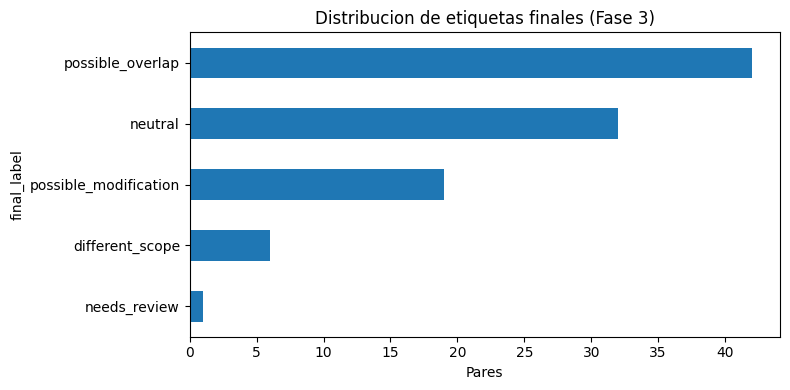

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))
label_counts.sort_values().plot(kind="barh", ax=ax)
ax.set_xlabel("Pares")
ax.set_title("Distribucion de etiquetas finales (Fase 3)")
plt.tight_layout()
plt.show()

## 10. Golden set para evaluacion manual

Muestra estratificada por etiqueta predicha y banda de similitud, para garantizar presencia de
conflictos y demas etiquetas raras. Estratificar por la etiqueta que predijo el propio LLM introduce
sesgo de seleccion (no es una muestra aleatoria del corpus) — es un trade-off aceptado para poder
evaluar el acuerdo humano-LLM en cada etiqueta, incluidas las poco frecuentes; se documenta en el
informe de Fase 5.

In [19]:
GOLDEN_SET_SIZE = 80

strata = candidate_classifications.copy()
strata["similarity_band"] = pd.cut(
    strata["similarity_score"],
    bins=[0.0, 0.97, 0.99, 1.0],
    labels=["0.957-0.97", "0.97-0.99", "0.99-1.0"],
    include_lowest=True,
)

golden_parts = [
    group.sample(n=min(len(group), 3), random_state=RANDOM_SEED)
    for _, group in strata.groupby(["final_label", "similarity_band"], observed=True)
]
golden_sample = pd.concat(golden_parts) if golden_parts else strata.iloc[0:0].copy()

if len(golden_sample) < GOLDEN_SET_SIZE:
    remaining = strata.drop(golden_sample.index)
    extra_n = min(len(remaining), GOLDEN_SET_SIZE - len(golden_sample))
    if extra_n > 0:
        extra = remaining.sample(n=extra_n, random_state=RANDOM_SEED)
        golden_sample = pd.concat([golden_sample, extra])

golden_sample = golden_sample.drop_duplicates("pair_key").head(GOLDEN_SET_SIZE).copy()

text_lookup = pd.read_parquet(FRAGMENTS_PATH, columns=["fragment_id", "text"]).set_index("fragment_id")["text"]
golden_sample["text_a"] = golden_sample["fragment_a_id"].map(text_lookup)
golden_sample["text_b"] = golden_sample["fragment_b_id"].map(text_lookup)
golden_sample["human_label"] = ""
golden_sample["human_notes"] = ""

GOLDEN_SET_PATH = OUTPUT_DIR / "golden_set_para_etiquetar.csv"
golden_cols = [
    "pair_key", "fragment_a_id", "fragment_b_id", "text_a", "text_b", "final_label", "final_confidence",
    "final_explanation", "similarity_score", "has_infoleg_relation", "human_label", "human_notes",
]
golden_sample[golden_cols].to_csv(GOLDEN_SET_PATH, index=False, encoding="utf-8")
print(f"Guardado: {GOLDEN_SET_PATH} ({len(golden_sample):,} pares para etiquetar a mano)")

del text_lookup
gc.collect()

Guardado: C:\Users\Lucas\documents\projects\tpsudesa\NLP\LexAr\outputs\golden_set_para_etiquetar.csv (80 pares para etiquetar a mano)


0

### 10.1 Guia de etiquetado

Abrir `outputs/golden_set_para_etiquetar.csv`, completar la columna `human_label` con una de las 6
etiquetas exactas (mismo criterio que el prompt de clasificacion) y guardar. `human_notes` es libre.

- possible_conflict: los fragmentos establecen obligaciones, prohibiciones, permisos, plazos o
  requisitos incompatibles entre si para una misma situacion.
- possible_overlap: los fragmentos regulan lo mismo de forma equivalente o redundante, sin
  incompatibilidad real (duplicacion, no contradiccion).
- possible_modification: uno de los fragmentos parece modificar, actualizar, ampliar o restringir
  al otro (por ejemplo, una norma posterior sobre el mismo punto).
- different_scope: el texto es similar pero aplica a sujetos, situaciones, epocas o ambitos
  distintos, por lo que no hay tension real.
- neutral: no se detecta ninguna tension ni relacion relevante mas alla de similitud superficial.
- needs_review: la comparacion es ambigua, falta contexto del articulo, o no se puede decidir con
  confianza entre las categorias anteriores.

Cuando este completo, correr la seccion 11 para calcular el acuerdo humano-LLM.

## 11. Evaluacion (correr despues de etiquetar el golden set)

In [20]:
if GOLDEN_SET_PATH.exists():
    labeled = pd.read_csv(GOLDEN_SET_PATH)
    labeled = labeled[labeled["human_label"].notna() & (labeled["human_label"].astype(str).str.strip() != "")]
    if labeled.empty:
        print("El golden set todavia no tiene 'human_label' completado. Etiquetar el CSV y volver a correr esta celda.")
    else:
        agreement = (labeled["human_label"] == labeled["final_label"]).mean()
        print(f"Pares etiquetados: {len(labeled):,}")
        print(f"Acuerdo humano-LLM global: {agreement:.1%}")
        print()
        print("Matriz de confusion (filas=humano, columnas=LLM):")
        print(pd.crosstab(labeled["human_label"], labeled["final_label"]))
        print()
        llm_conflict = labeled["final_label"] == "possible_conflict"
        if llm_conflict.any():
            human_conflict = labeled["human_label"] == "possible_conflict"
            precision_at_k = (human_conflict & llm_conflict).sum() / llm_conflict.sum()
            print(f"Precision@K sobre possible_conflict (K={llm_conflict.sum()}): {precision_at_k:.1%}")
else:
    print("Todavia no existe el golden set. Correr la seccion 10 primero.")

El golden set todavia no tiene 'human_label' completado. Etiquetar el CSV y volver a correr esta celda.


## Resultado de Fase 3

Salidas en `outputs/` (gitignoreado):

- `candidate_classifications.parquet` — una fila por par en alcance (`similarity_score >= 0.957`),
  con `final_label`, `final_confidence`, `final_explanation`, `final_model`, `rule_applied` y las
  columnas intermedias `triage_label`/`verify_label`.
- `conflicts_top.csv` — pares `possible_conflict` verificados, con texto completo, para revision manual.
- `golden_set_para_etiquetar.csv` — muestra estratificada para evaluacion humana.
- `classification/part_*.parquet`, `classification_verify/part_*.parquet` — checkpoints reanudables
  del triage y la verificacion (no se versionan).